# Import packages and Loading Data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from scipy.stats import kruskal
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings
warnings.filterwarnings('ignore')

2026-03-09 08:24:48.733483: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773044688.759104     147 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773044688.766436     147 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773044688.785191     147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773044688.785220     147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773044688.785223     147 computation_placer.cc:177] computation placer alr

In [ ]:
data_path = Path("Radiomics/radiomics_dataset.csv")
data = pd.read_csv(data_path)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (25, 18)


,original_shape_Sphericity,original_shape_SurfaceVolumeRatio,original_shape_Maximum3DDiameter,original_glcm_Contrast,original_glcm_Correlation,original_glcm_Idm,original_glszm_SmallAreaEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_ZonePercentage,original_glrlm_ShortRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_RunPercentage,scan_id,calcium_mean_HU,calcium_max_HU,calcium_volume,agatston_score,agatston_category
0,0.072331,2.019372,269.408612,2.071452,0.415838,0.725623,0.708333,2.218106e+08,0.000164,0.567656,10527.963812,0.559109,46742729e228,2.018335,157.0,36487.0,1.252476,1-99
1,0.071783,2.019655,272.237029,9.249506,0.189567,0.506717,0.606692,3.153382e+07,0.001179,0.756046,5811.744566,0.695232,29ec4b3ec827,2.235773,309.0,37324.0,35.097134,1-99
2,0.070841,2.018618,277.893865,10.323305,0.035358,0.511755,0.721877,3.673509e+07,0.001054,0.751008,6164.963005,0.695113,6dd2b59a3e9a,2.236002,279.0,38881.0,36.715057,1-99
3,0.069608,2.007535,284.964910,30.671997,0.489209,0.438633,0.709608,3.100501e+06,0.012870,0.914468,1841.251752,0.700454,8d6ae1cee7d9,6.272522,879.0,41725.0,879.138916,>=400
4,0.073482,2.017791,262.337569,17.193943,0.377757,0.470457,0.734498,6.686504e+06,0.005129,0.849600,3064.518042,0.697104,844984be0336,3.314395,559.0,34902.0,244.018570,100-399


In [3]:
data.columns.tolist()

['original_shape_Sphericity',
 'original_shape_SurfaceVolumeRatio',
 'original_shape_Maximum3DDiameter',
 'original_glcm_Contrast',
 'original_glcm_Correlation',
 'original_glcm_Idm',
 'original_glszm_SmallAreaEmphasis',
 'original_glszm_LargeAreaEmphasis',
 'original_glszm_ZonePercentage',
 'original_glrlm_ShortRunEmphasis',
 'original_glrlm_LongRunEmphasis',
 'original_glrlm_RunPercentage',
 'scan_id',
 'calcium_mean_HU',
 'calcium_max_HU',
 'calcium_volume',
 'agatston_score',
 'agatston_category']

In [4]:
# List of features (excluding scan_id, agatston columns)
selected_features = [
    'original_shape_Sphericity',
    'original_shape_SurfaceVolumeRatio',
    'original_shape_Maximum3DDiameter',
    'original_glcm_Contrast',
    'original_glcm_Correlation',
    'original_glcm_Idm',
    'original_glszm_SmallAreaEmphasis',
    'original_glszm_LargeAreaEmphasis',
    'original_glszm_ZonePercentage',
    'original_glrlm_ShortRunEmphasis',
    'original_glrlm_LongRunEmphasis',
    'original_glrlm_RunPercentage',
    'calcium_mean_HU',
    'calcium_max_HU',
    'calcium_volume'
]

# Statical Analysis

## Spearman

In [5]:
# Spearman correlation
spearman_results = []
for feat in selected_features:
    coef, p = spearmanr(data[feat], data['agatston_score'])
    spearman_results.append({
        'feature': feat,
        'spearman_corr': coef,
        'p_value': p
    })

spearman_df = pd.DataFrame(spearman_results).sort_values('p_value')
print(spearman_df)

                              feature  spearman_corr       p_value
12                    calcium_mean_HU       0.992308  2.247454e-22
8       original_glszm_ZonePercentage       0.988462  2.336893e-20
9     original_glrlm_ShortRunEmphasis       0.980000  1.252887e-17
7    original_glszm_LargeAreaEmphasis      -0.973077  3.696838e-16
11       original_glrlm_RunPercentage       0.972308  5.092064e-16
10     original_glrlm_LongRunEmphasis      -0.961538  2.111802e-14
13                     calcium_max_HU       0.931333  1.427561e-11
3              original_glcm_Contrast       0.806154  1.146674e-06
5                   original_glcm_Idm      -0.797692  1.792401e-06
1   original_shape_SurfaceVolumeRatio      -0.539231  5.409304e-03
4           original_glcm_Correlation       0.509231  9.325053e-03
6    original_glszm_SmallAreaEmphasis       0.190769  3.610105e-01
2    original_shape_Maximum3DDiameter      -0.033481  8.737650e-01
0           original_shape_Sphericity       0.022308  9.157086

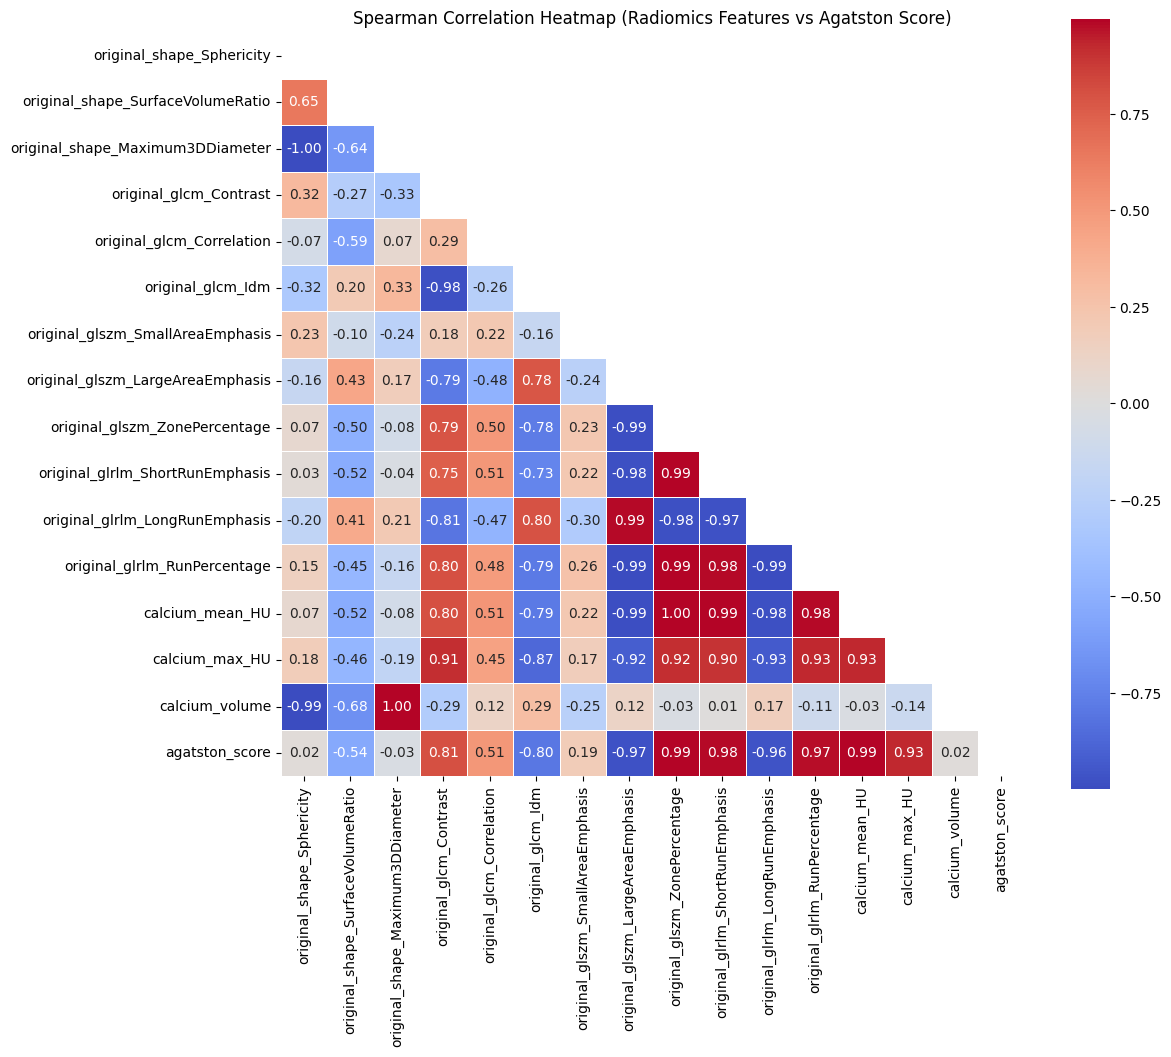

In [6]:
#  Compute Spearman correlation matrix and plot heatmap

corr_features = selected_features + ['agatston_score']
corr_matrix = data[corr_features].corr(method='spearman')
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidth= 0.5, annot=True, fmt=".2f", square=True, mask=np.triu(np.ones_like(corr_matrix, dtype=bool)))
plt.title("Spearman Correlation Heatmap (Radiomics Features vs Agatston Score)")
plt.show()

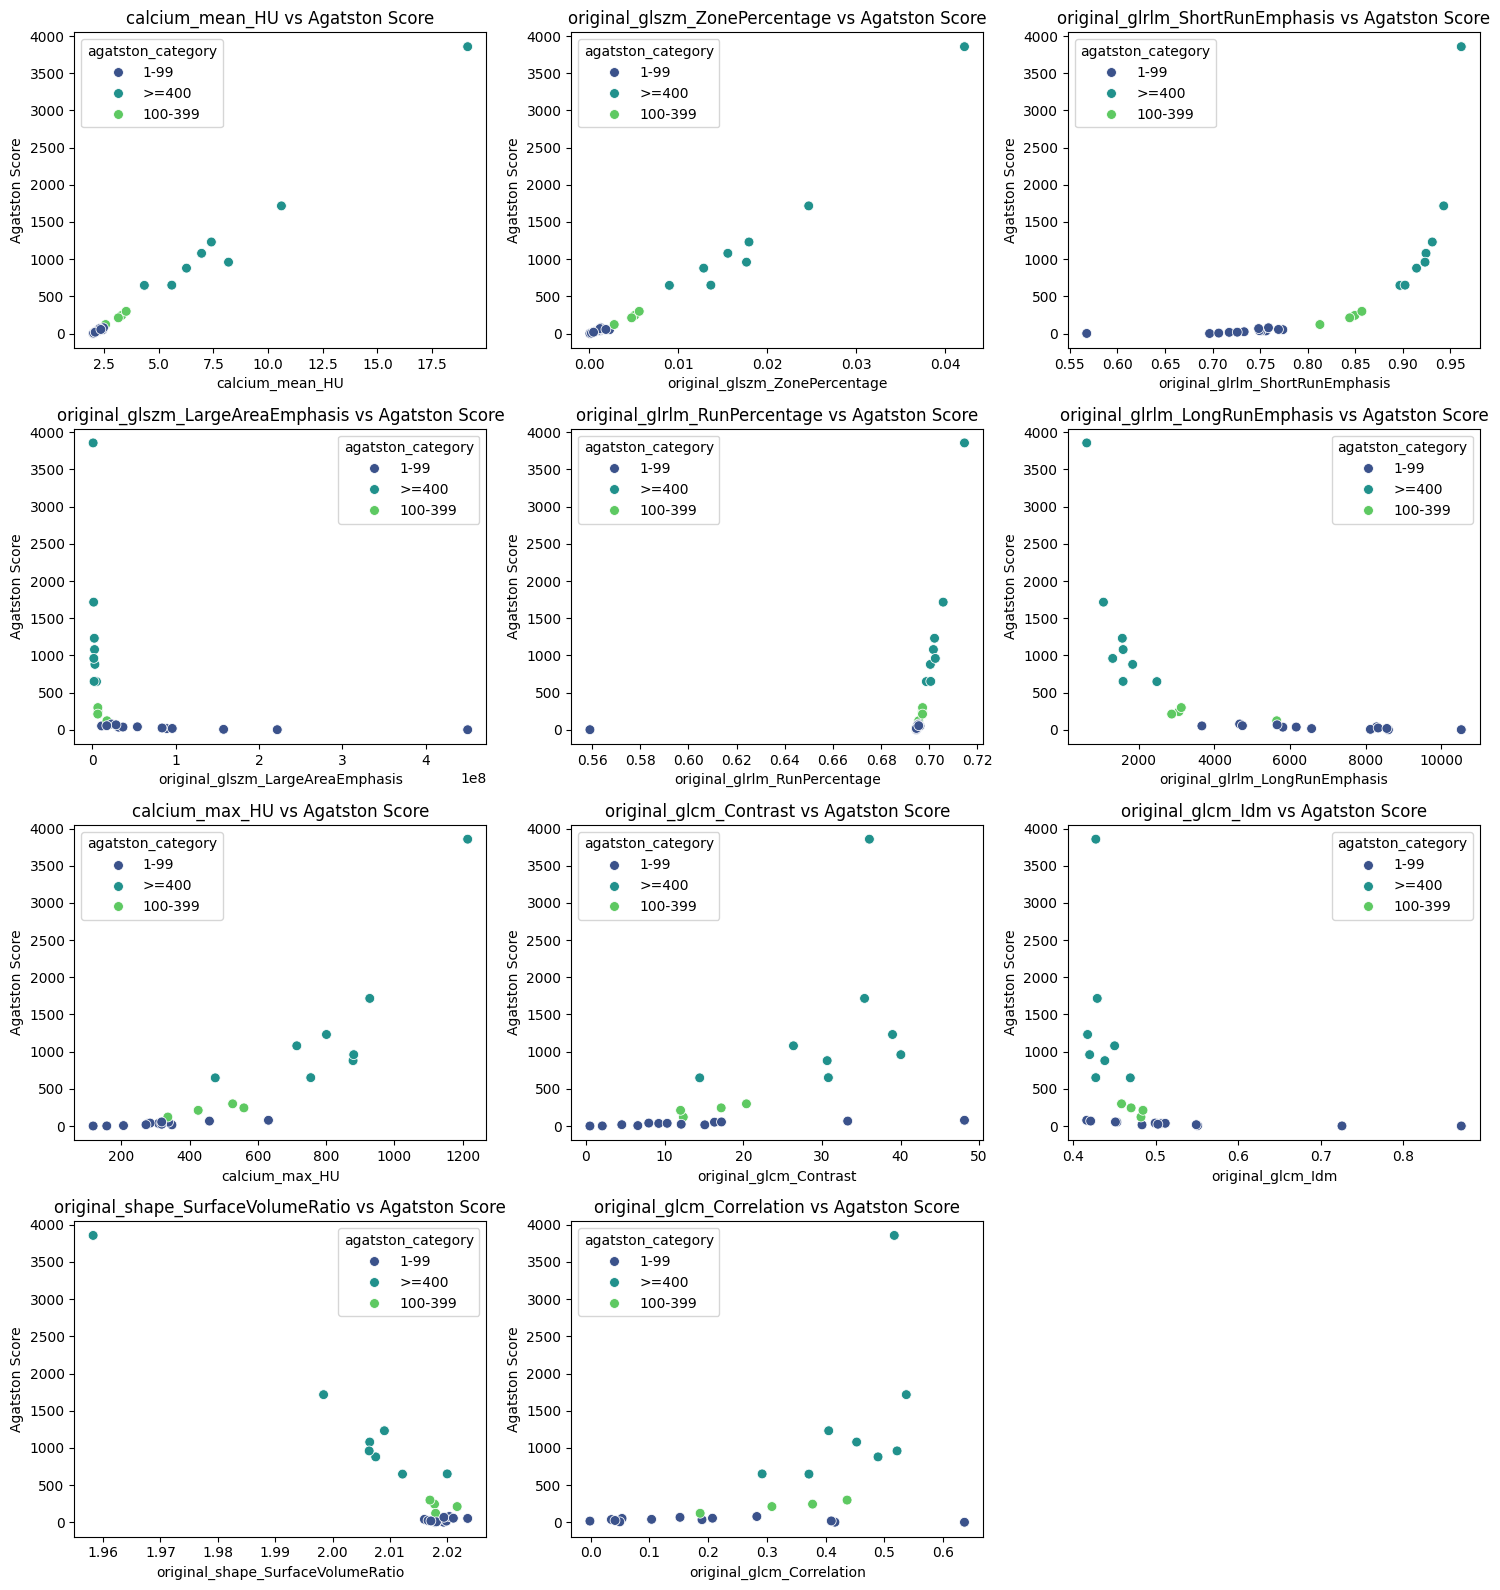

In [7]:
# scatter plot for significant features 

# Significant features to plot
sig_spearman_features = spearman_df[spearman_df['p_value'] < 0.05]['feature'].tolist()

num_feats = len(sig_spearman_features)
cols = 3  
rows = math.ceil(num_feats / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.flatten()  

for i, feat in enumerate(sig_spearman_features):
    sns.scatterplot(
        data=data,
        x=feat,
        y='agatston_score',
        hue='agatston_category',  
        palette="viridis",
        s=50,
        ax=axes[i]
    )
    axes[i].set_title(f"{feat} vs Agatston Score")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Agatston Score")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Spearman Correlation Summary

The Spearman correlation analysis was performed to investigate the monotonic relationships between extracted radiomic features and the Agatston score. Spearman correlation coefficients (rho) quantify the strength and direction of these associations, while the corresponding p-values indicate statistical significance, Features with p-values < 0.05 were considered statistically significant and were visualized using **scatter plots** with points colored by Agatston score category (1–99, 100–399, ≥400).

## Key observations:

### - Calcium Density Measures

- `calcium_mean_HU` (rho = 0.992, p << 0.001) and `calcium_max_HU` (rho = 0.931, p << 0.001) show extremely strong positive correlations with Agatston score.

- Interpretation: Higher mean and maximum calcium attenuation directly contribute to higher Agatston scores, as expected, since Agatston scoring is based on both the area and density of calcified lesions.

### - Texture Features

- `original_glszm_ZonePercentage` (rho = 0.988) and `original_glrlm_ShortRunEmphasis` (rho = 0.980) are also highly positively correlated.

- Interpretation: These features capture the presence of small, dense, or short runs of high-intensity voxels. Their increase reflects more heterogeneous and concentrated calcification regions, leading to higher Agatston scores.

- Conversely, `original_glszm_LargeAreaEmphasis` (rho = -0.973) and `original_glrlm_LongRunEmphasis` (rho = -0.962) are strongly negatively correlated.

- Interpretation: Larger homogeneous regions (high values of these features) are inversely related to calcification burden, indicating that extensive uniform tissue tends to have lower Agatston scores.

### - GLCM Features

- `original_glcm_Contrast` (rho = 0.806) shows a strong positive correlation, reflecting that increased intensity differences within the ROI are associated with higher calcification.

-  `original_glcm_Idm` (rho = -0.798) shows a strong negative correlation, indicating that more homogeneous regions (higher IDM) are associated with lower Agatston scores.

### - Shape Features

- `original_shape_SurfaceVolumeRatio` (rho = -0.539) shows a weak negative correlation, while `original_shape_Maximum3DDiameter` and `original_shape_Sphericity` (rho ≈ 0) show negligible correlation.

- Interpretation: Overall shape characteristics of the segmented calcium regions do not strongly influence Agatston scoring in this cohort.

### - Volume Feature

- `calcium_volume` (rho ≈ 0) has minimal correlation with Agatston score.

- Interpretation: Volume alone is insufficient to predict the score; density and spatial distribution are more important.

### - Conclusion:
The most predictive features of Agatston score are calcium density (mean/max HU) and selected texture features (GLSZM/GLRLM). Shape and volume features are less informative. These insights can guide subsequent modeling, feature selection, and phenotype characterization.

## Kruskal-Wallis 

In [8]:
# Prepare list to store results
kw_results = []

for feat in selected_features:
    # Groups by Agatston category
    groups = [data[data['agatston_category']==cat][feat] for cat in data['agatston_category'].unique()]
    
    # Kruskal-Wallis test
    stat, p = kruskal(*groups)
    
    kw_results.append({
        'feature': feat,
        'kruskal_stat': stat,
        'p_value': p
    })

kw_df = pd.DataFrame(kw_results).sort_values('p_value')
print(kw_df)

                              feature  kruskal_stat   p_value
9     original_glrlm_ShortRunEmphasis     19.772308  0.000051
12                    calcium_mean_HU     19.772308  0.000051
8       original_glszm_ZonePercentage     19.772308  0.000051
7    original_glszm_LargeAreaEmphasis     19.168757  0.000069
11       original_glrlm_RunPercentage     19.168757  0.000069
10     original_glrlm_LongRunEmphasis     18.885089  0.000079
13                     calcium_max_HU     16.591411  0.000250
1   original_shape_SurfaceVolumeRatio     10.413195  0.005480
3              original_glcm_Contrast      9.213195  0.009986
4           original_glcm_Correlation      9.052189  0.010823
5                   original_glcm_Idm      9.044201  0.010866
6    original_glszm_SmallAreaEmphasis      2.672663  0.262808
14                     calcium_volume      0.596272  0.742200
0           original_shape_Sphericity      0.445740  0.800219
2    original_shape_Maximum3DDiameter      0.382098  0.826092


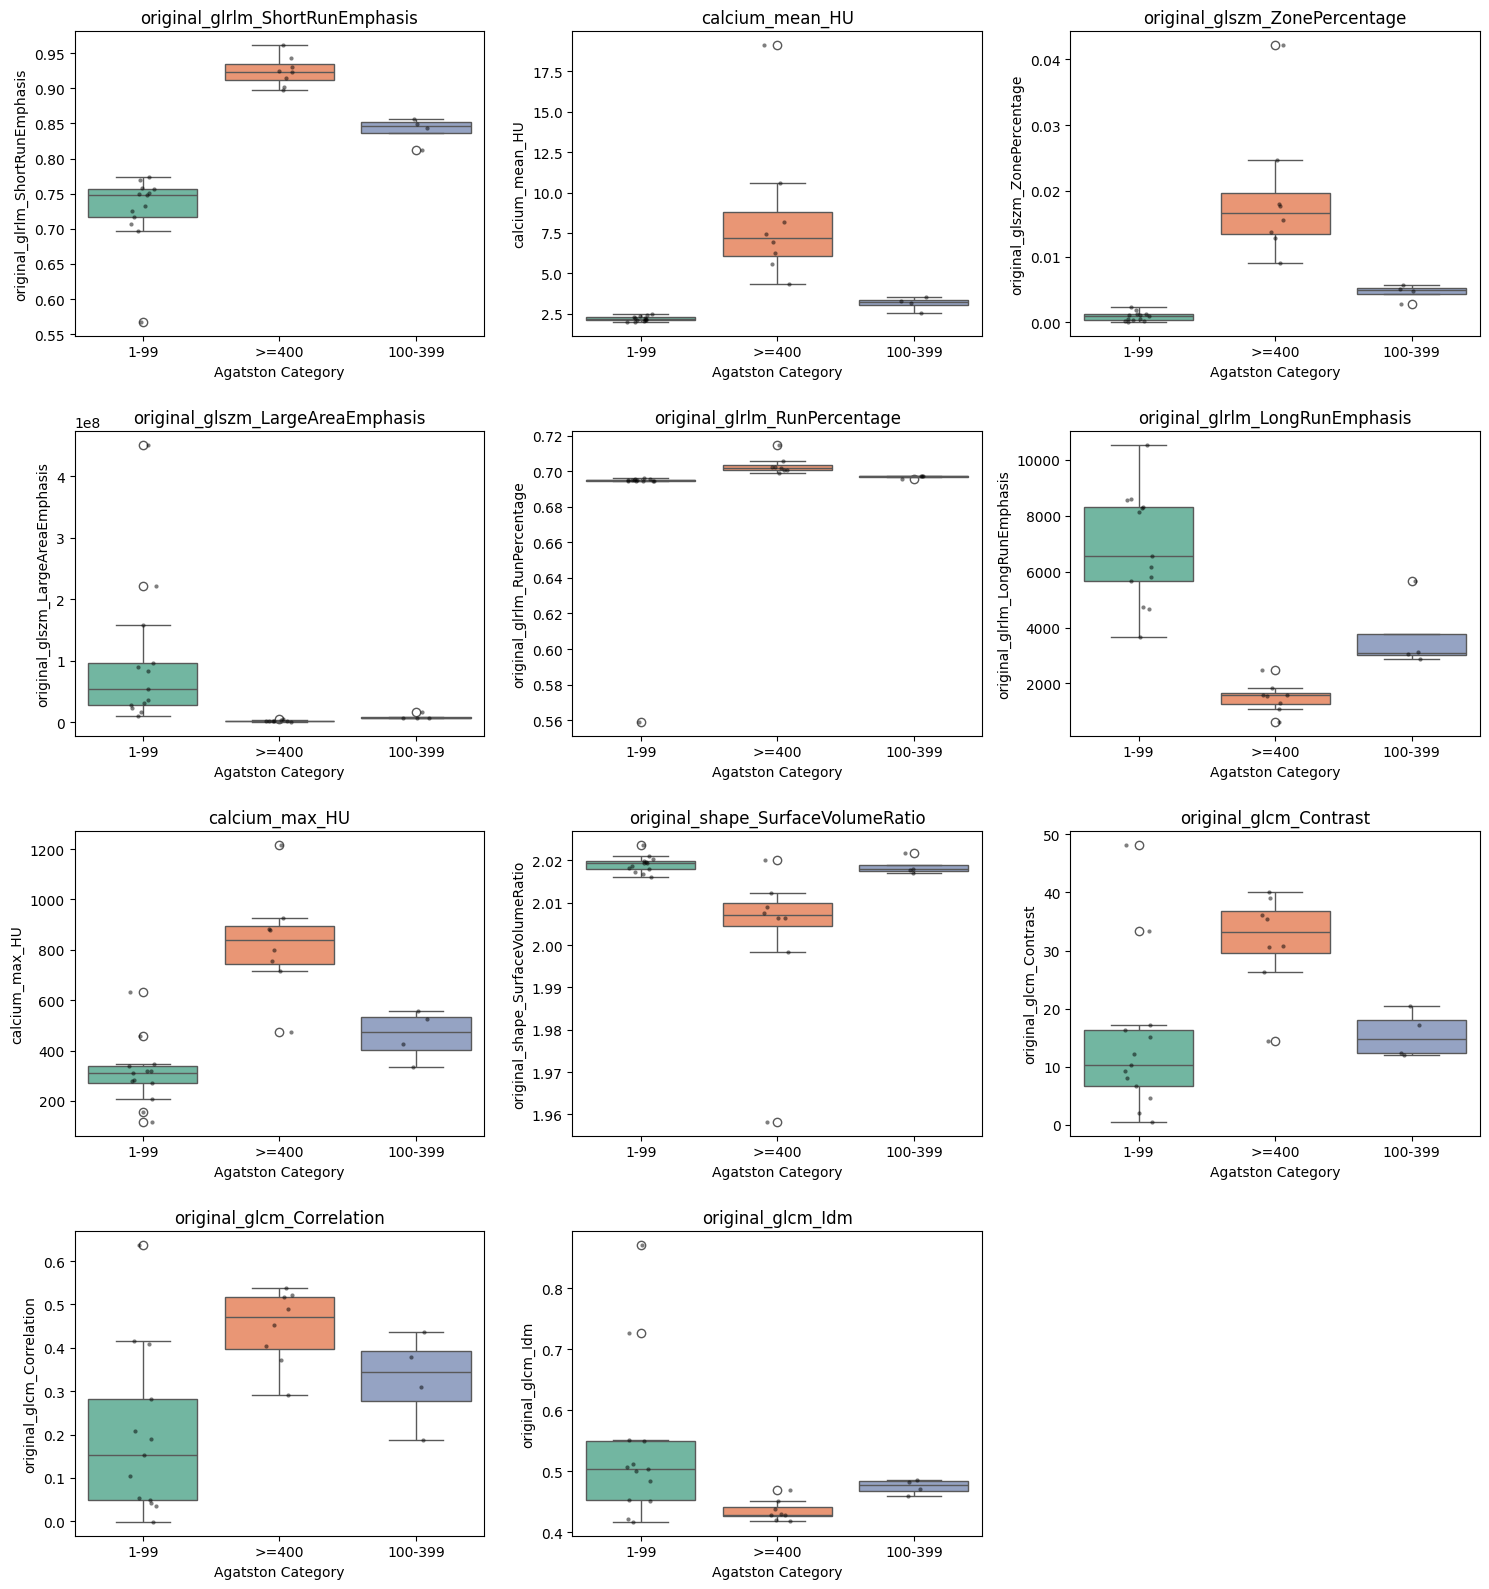

In [9]:
# Boxplot for significant features

# Select significant features
sig_kw_features = kw_df[kw_df['p_value'] < 0.05]['feature'].tolist()

n_features = len(sig_kw_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()  

# Loop over features and plot each on its subplot
for i, feat in enumerate(sig_kw_features):
    sns.boxplot(
        data=data,
        x='agatston_category',
        y=feat,
        palette="Set2",
        ax=axes[i]
    )
    sns.stripplot(
        data=data,
        x='agatston_category',
        y=feat,
        color='black',
        size=3,
        jitter=True,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel("Agatston Category")
    axes[i].set_ylabel(feat)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Kruskal-Wallis Test & Visualization Summary

The Kruskal-Wallis test was performed to evaluate whether each selected radiomics feature differs significantly across Agatston score categories (0, 1–99, 100–399, ≥400). Features with p < 0.05 were further explored using boxplots with overlaid strip plots to visualize their distribution across severity levels.

## Key Observations

### Calcium Density Features
- `calcium_mean_HU` and `calcium_max_HU` show very strong differences across categories (p << 0.001).  
- **Interpretation:** Higher HU values correspond to higher Agatston scores, confirming that denser plaques are associated with increased calcium burden.

### Texture Features (GLRLM & GLSZM)
- `original_glrlm_ShortRunEmphasis`, `original_glrlm_RunPercentage`, and `original_glszm_ZonePercentage` increase with higher Agatston categories.  
- `original_glrlm_LongRunEmphasis` and `original_glszm_LargeAreaEmphasis` decrease with severity.  
- **Interpretation:** High-score plaques are more heterogeneous and contain fine, dense, or short-run patterns. Larger homogeneous regions are more common in low-score plaques.

### Shape Features
- `original_shape_SurfaceVolumeRatio` shows moderate differences; `original_shape_Sphericity` and `original_shape_Maximum3DDiameter` are not significant.  
- **Interpretation:** Plaque geometry contributes modestly to calcium burden; shape alone is less informative than texture or intensity.

### Volume Feature
- `calcium_volume` is not significant (p ≈ 0.74).  
- **Interpretation:** Volume alone does not discriminate between risk categories; density and texture are more informative.

### GLCM Features
- `original_glcm_Contrast` increases with severity, while `original_glcm_Correlation` shows moderate changes.  
- **Interpretation:** Reflects greater intensity variation and altered spatial relationships within calcified regions.

## Visual Insights from Boxplots
- Clear median shifts between Agatston categories for significant features.  
- Severe cases (≥400) show higher variability, highlighting heterogeneous plaque composition.  
- Strip plots confirm that observed differences are consistent across samples and not driven by outliers.

## Conclusion
Kruskal-Wallis statistics and boxplot visualizations together demonstrate that **radiomic texture and intensity features** strongly differentiate between Agatston categories, while **shape and volume features** contribute more modestly.  
These results support the potential use of radiomic features as **quantitative biomarkers for coronary artery calcification severity**.


## t-SNE

In [14]:
X = data[selected_features].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create t-SNE embedding
tsne = TSNE(n_components=2, perplexity=15, random_state=42)  # n_components=2 for 2D visualization
X_tsne = tsne.fit_transform(X_scaled)

# Add t-SNE results to the DataFrame
data['tSNE_1'] = X_tsne[:, 0]  
data['tSNE_2'] = X_tsne[:, 1]  

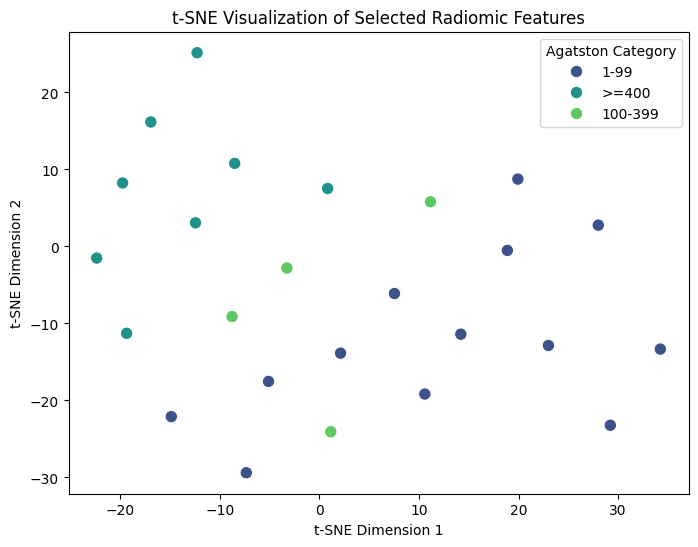

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x='tSNE_1',
    y='tSNE_2',
    hue='agatston_category',  
    palette='viridis',       
    s=80                      
)
plt.title("t-SNE Visualization of Selected Radiomic Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Agatston Category")
plt.show()

# t-SNE Summary

t-SNE was used to reduce the radiomic feature space into two dimensions for visualization. The plot shows some separation between Agatston categories, where high-score cases (≥400) tend to cluster in similar regions, while mild cases (1–99) are more spread out. Moderate cases (100–399) generally appear between the two groups.

Some overlap is expected since the analysis was performed on only **25 scan samples**. With a larger dataset, the separation between categories may become clearer. Overall, the visualization suggests that the radiomic features capture patterns related to calcium severity.

## UMAP

In [16]:
# create a UMAP readucer
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

data['UMAP_1'] = X_umap[:,0]
data['UMAP_2'] = X_umap[:,1]

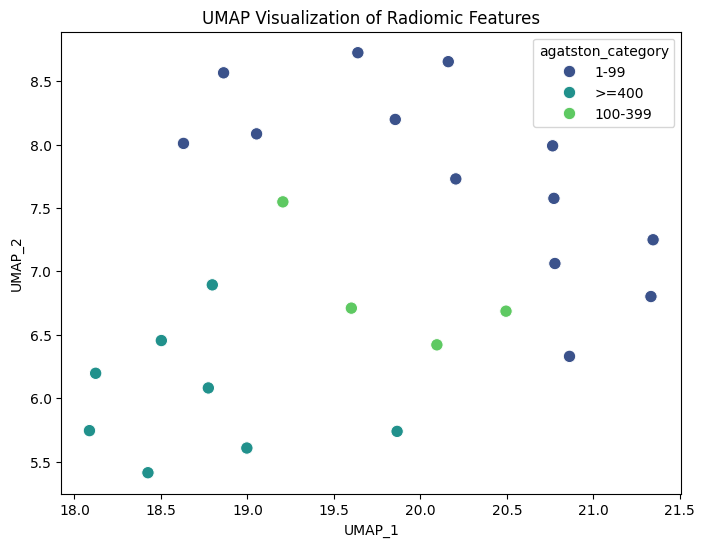

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='UMAP_1', y='UMAP_2', 
    hue='agatston_category', 
    data=data,
    palette="viridis",
    s=80
)
plt.title("UMAP Visualization of Radiomic Features")
plt.show()

I see here, UMAP sperate categories better than t-SNE

# Unsupervised Learning

## Hierarchical Clustering

In [18]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)

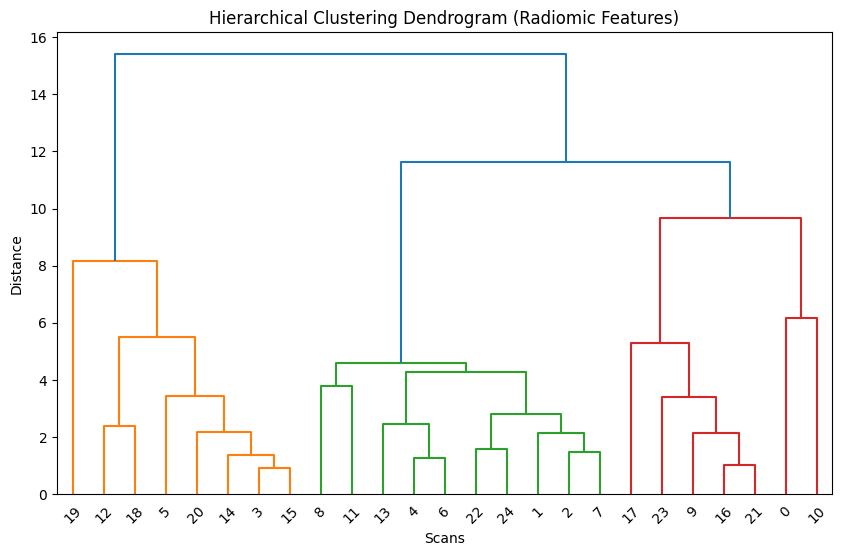

In [19]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram (Radiomic Features)")
plt.xlabel("Scans")
plt.ylabel("Distance")

plt.show()

In [20]:
# Evaluate Hierarchical clustering using common clustering metrics
sil_hc = silhouette_score(X_scaled, labels_hc)
cal_hc = calinski_harabasz_score(X_scaled, labels_hc)
db_hc = davies_bouldin_score(X_scaled, labels_hc)

## K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

In [22]:
# Evaluate K-Means clustering using common clustering metrics

sil_km = silhouette_score(X_scaled, labels_kmeans)
cal_km = calinski_harabasz_score(X_scaled, labels_kmeans)
db_km = davies_bouldin_score(X_scaled, labels_kmeans)

## Comparison between Clustering Results 

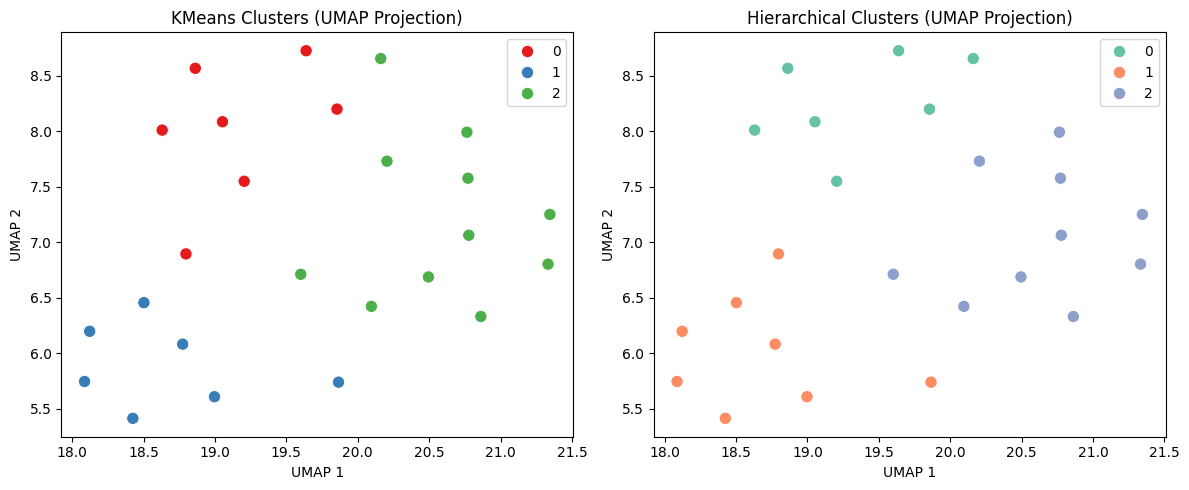

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# KMeans clusters
sns.scatterplot(
    x=data['UMAP_1'],
    y=data['UMAP_2'],
    hue=labels_kmeans,
    palette='Set1',
    s=80,
    ax=axes[0]
)

axes[0].set_title("KMeans Clusters (UMAP Projection)")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Hierarchical clusters
sns.scatterplot(
    x=data['UMAP_1'],
    y=data['UMAP_2'],
    hue=labels_hc,
    palette='Set2',
    s=80,
    ax=axes[1]
)

axes[1].set_title("Hierarchical Clusters (UMAP Projection)")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

In [25]:
comparison = pd.DataFrame({

    "Method": ["Hierarchical", "KMeans"],

    "Silhouette Score": [sil_hc, sil_km],

    "Calinski-Harabasz Score": [cal_hc, cal_km],

    "Davies-Bouldin Score": [db_hc, db_km]

})

comparison

,Method,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,Hierarchical,0.266295,10.846814,1.191868
1,KMeans,0.262293,9.611152,1.290367


## Clustering Insights

Both **K-Means** and **Hierarchical clustering** produced similar grouping patterns, suggesting that the dataset contains a consistent underlying cluster structure. **Hierarchical** achieved a slightly higher **Silhouette score**, indicating better separation between clusters, also obtained a higher **Calinski–Harabasz score** and a slightly lower **Davies–Bouldin score**, suggesting more compact clusters.

Overall, the results indicate that the dataset exhibits **some natural grouping**, although the cluster boundaries are not strongly separated. Since the analysis was performed on **only 25 samples**, using **Whole dataset** will help these patterns become more clearly defined, potentially improving cluster separation and stability.